In [190]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('survey.csv')
print(df.describe())
print(df.head())

       surveyDistance  surveyAngle         GPS_x         GPS_y     GPS_alt
count       37.000000    37.000000     37.000000     37.000000   37.000000
mean         4.191892    -2.905405  85149.405405  33843.108108  473.162162
std          2.143385    13.194505     11.910452     41.924392    5.809540
min          0.000000   -28.000000  85125.000000  33779.000000  466.000000
25%          2.600000   -12.000000  85140.000000  33813.000000  468.000000
50%          4.300000    -6.000000  85152.000000  33831.000000  474.000000
75%          5.000000     2.000000  85160.000000  33877.000000  478.000000
max          8.800000    31.000000  85165.000000  33923.000000  483.000000
   surveyDistance  surveyAngle  GPS_x  GPS_y  GPS_alt
0             0.0          0.0  85125  33923      483
1             5.0         -2.5  85128  33918      481
2             7.0         -4.5  85129  33911      482
3             7.0         -4.0  85132  33904      481
4             5.0         -6.0  85135  33899      482


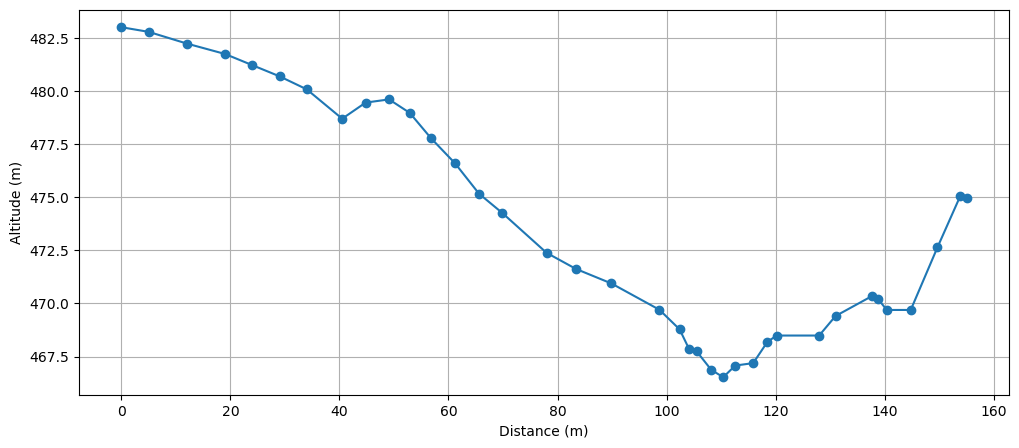

In [191]:
df['distanceSurvey'] = 0.0
df['altSurvey'] = 0.0

startAlt = df['GPS_alt'].iloc[0]

for i in range(0, len(df)):
    angleRad = np.deg2rad(df["surveyAngle"].iloc[i])
    altChange = df["surveyDistance"].iloc[i] * np.tan(angleRad)
    
    if i == 0:
        df.at[i, "distanceSurvey"] = df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = startAlt + altChange
    else:
        df.at[i, "distanceSurvey"] = df.at[i-1, "distanceSurvey"] + df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = df.at[i-1, "altSurvey"] + altChange


plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o')
plt.xlabel('Distance (m)')
plt.ylabel('Altitude (m)')
plt.grid(True)
plt.show()

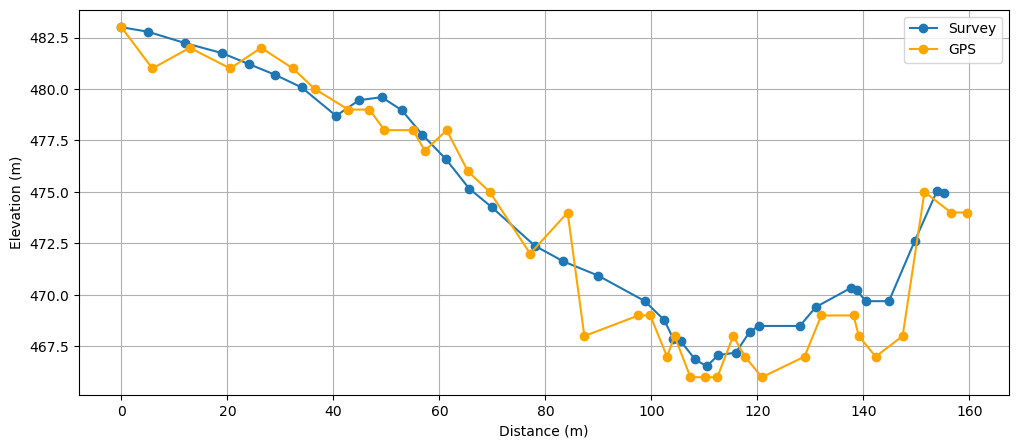

   surveyDistance  surveyAngle   GPS_x   GPS_y  GPS_alt  distanceSurvey  \
0             0.0          0.0  385125  533923      483             0.0   
1             5.0         -2.5  385128  533918      481             5.0   
2             7.0         -4.5  385129  533911      482            12.0   
3             7.0         -4.0  385132  533904      481            19.0   
4             5.0         -6.0  385135  533899      482            24.0   

    altSurvey  distanceGPS  
0  483.000000     0.000000  
1  482.781695     5.830952  
2  482.230783    12.902020  
3  481.741296    20.517793  
4  481.215774    26.348745  


In [192]:
for i in range(len(df)):
    df.at[i, "GPS_x"]  = df.at[i, "GPS_x"]  + 300000
    df.at[i, "GPS_y"]  = df.at[i, "GPS_y"]  + 500000

df['distanceGPS'] = 0.0

for i in range(len(df)):
    if i == 0:
        # distanceGPS[i] = 0
        df.at[i, "distanceGPS"] = 0.0
    else:
        delta_easting = df.at[i, "GPS_x"] - df.at[i-1, "GPS_x"] 
        delta_northing = df.at[i, "GPS_y"] - df.at[i-1, "GPS_y"] 
        segment_distance = np.sqrt(delta_easting**2 + delta_northing**2)
        df.at[i, "distanceGPS"]  = df.at[i-1, "distanceGPS"]  + segment_distance

plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
# plt.plot(distanceSurvey, altSurvey, marker='o')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()

print(df.head())


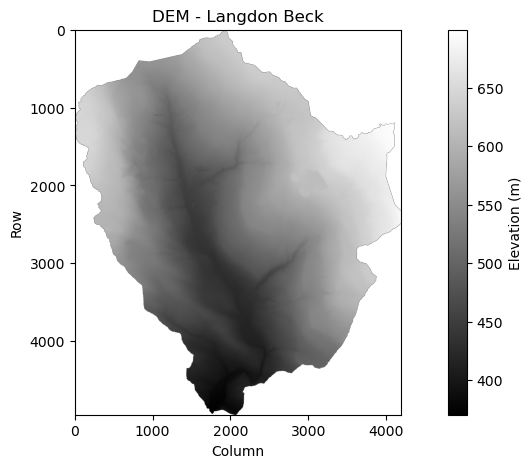

In [193]:
# Read in LiDAR data
import rasterio
dem = rasterio.open('Langdon_Beck.tif')
dem_array = dem.read(1)
dem_array[dem_array == -9999] = np.nan
# print(dem.crs)

plt.figure(figsize=(12, 5))
plt.imshow(dem_array, cmap='gray')
plt.colorbar(label='Elevation (m)')
plt.title('DEM - Langdon Beck')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

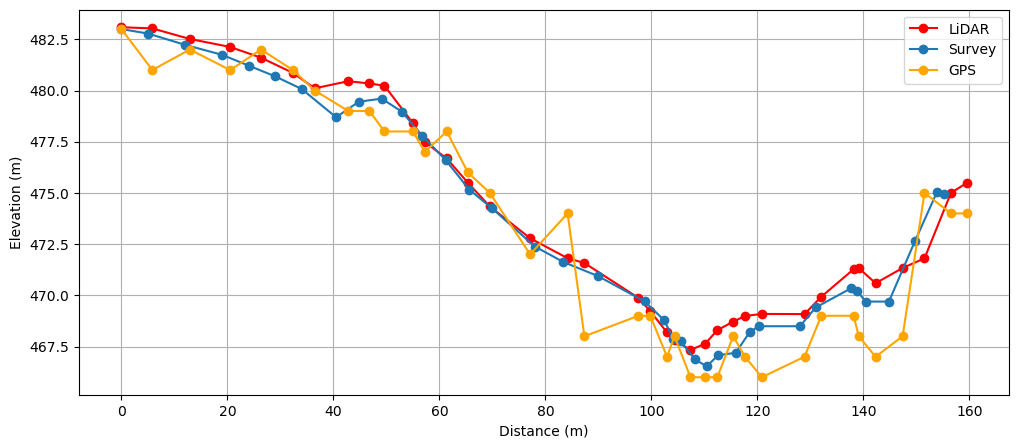

In [194]:

# Create list of (x, y) pairs from easting and northing
easting = df['GPS_x'].tolist()
northing = df['GPS_y'].tolist()
xy_pairs = list(zip(easting, northing))

# Extract DEM values at each location
dem_values = []
for x, y in xy_pairs:
    row, col = dem.index(x, y)
    n = dem.sample(x,y)
    dem_values.append(dem.read(1, window=((row, row+1), (col, col+1)))[0, 0])

elevationsDEM = np.array(dem_values)
df['elevationsDEM'] = elevationsDEM

plt.figure(figsize=(12, 5))
plt.plot(df['distanceGPS'], elevationsDEM, marker='o', color='red', label='LiDAR')
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()



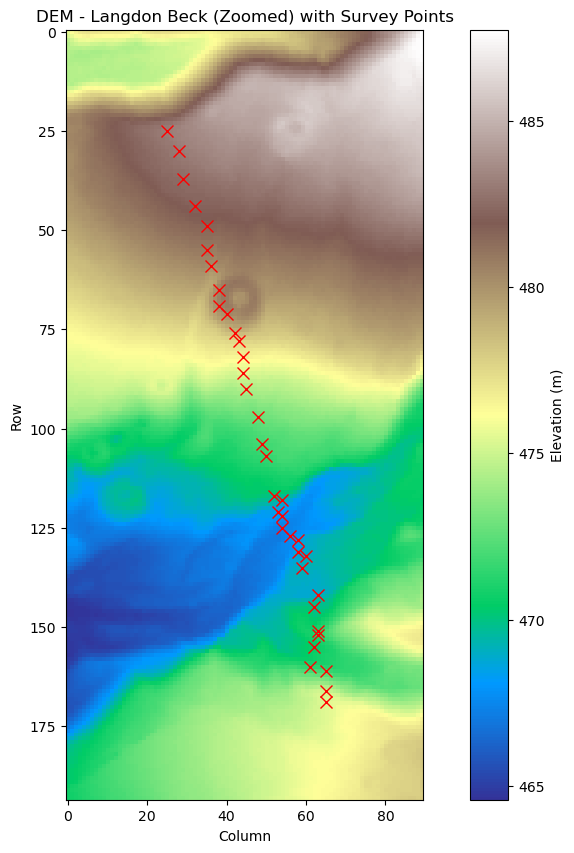

In [201]:

# Calculate bounds of survey points with buffer
buffer = 25  # meters
min_easting = min(easting) - buffer
max_easting = max(easting) + buffer
min_northing = min(northing) - buffer
max_northing = max(northing) + buffer

# Convert to pixel coordinates
min_row, min_col = dem.index(min_easting, max_northing)
max_row, max_col = dem.index(max_easting, min_northing)

# # Ensure coordinates are within bounds
# min_row = max(0, min_row)
# max_row = min(dem_array.shape, max_row)
# min_col = max(0, min_col)
# max_col = min(dem_array.shape, max_col)

# Extract zoomed DEM
dem_zoomed = dem_array[min_row:max_row, min_col:max_col]

# Plot zoomed DEM with survey points
plt.figure(figsize=(12, 10))
plt.imshow(dem_zoomed, cmap='terrain')
plt.colorbar(label='Elevation (m)')

# Overlay survey points
for x, y in xy_pairs:
    row, col = dem.index(x, y)
    plt.plot(col - min_col, row - min_row, 'rx', markersize=8)

plt.title('DEM - Langdon Beck (Zoomed) with Survey Points')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

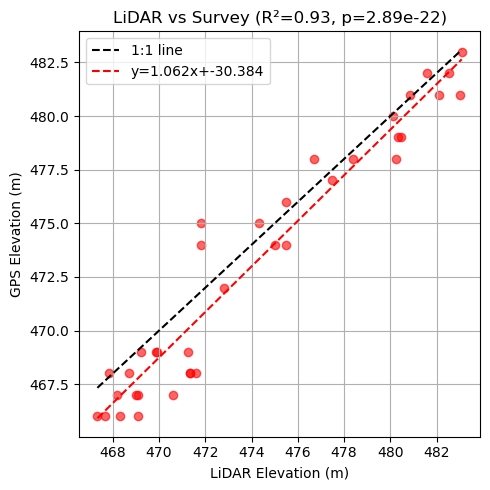

In [200]:
from scipy import stats

fig, axes = plt.subplots(figsize=(5, 5))

# Left plot: LiDAR vs GPS
axes.scatter(elevationsDEM, df['GPS_alt'], alpha=0.6, color='red')
axes.plot([min(elevationsDEM), max(elevationsDEM)], [min(elevationsDEM), max(elevationsDEM)], 'k--', label='1:1 line')

slope, intercept, r_value, p_value, std_err = stats.linregress(elevationsDEM, df['GPS_alt'])
line_x = np.array([elevationsDEM.min(), elevationsDEM.max()])
line_y = slope * line_x + intercept
axes.plot(line_x, line_y, 'r--', label=f'y={slope:.3f}x+{intercept:.3f}')

axes.set_xlabel('LiDAR Elevation (m)')
axes.set_ylabel('GPS Elevation (m)')
axes.set_title(f'LiDAR vs Survey (R²={r_value**2:.2f}, p={p_value:.2e})')
axes.grid(True)
axes.legend()
plt.tight_layout()
plt.show()